In [12]:
!pip install plotly

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [14]:
df_history= pd.DataFrame({
    'Month': [
        "Month 1", "Month 2", "Month 3", "Month 4", "Month 5", "Month 6", 
        "Month 7", "Month 8", "Month 9", "Month 10", "Month 11", "Month 12"
    ],
    'Actual_Revenue': [
        100000, 102000, 98000, 105000, 110000, 108000, 
        115000, 112000, 120000, 118000, 125000, 122000
    ],
    'Actual_Cost': [
        60000, 61000, 59000, 63000, 65000, 64000, 
        68000, 67000, 72000, 71000, 75000, 74000
    ]
})

In [6]:
df_history

,Month,Actual_Revenue,Actual_Cost
0,Month 1,100000,60000
1,Month 2,102000,61000
2,Month 3,98000,59000
3,Month 4,105000,63000
4,Month 5,110000,65000
5,Month 6,108000,64000
6,Month 7,115000,68000
7,Month 8,112000,67000
8,Month 9,120000,72000
9,Month 10,118000,71000


🚀 【Plotly 網頁級動態預測系統 6.0】已啟動！



💬 Please enter multiple drift rates (e.g., 0, 0.02, -0.01):  -0.02,0,0.03


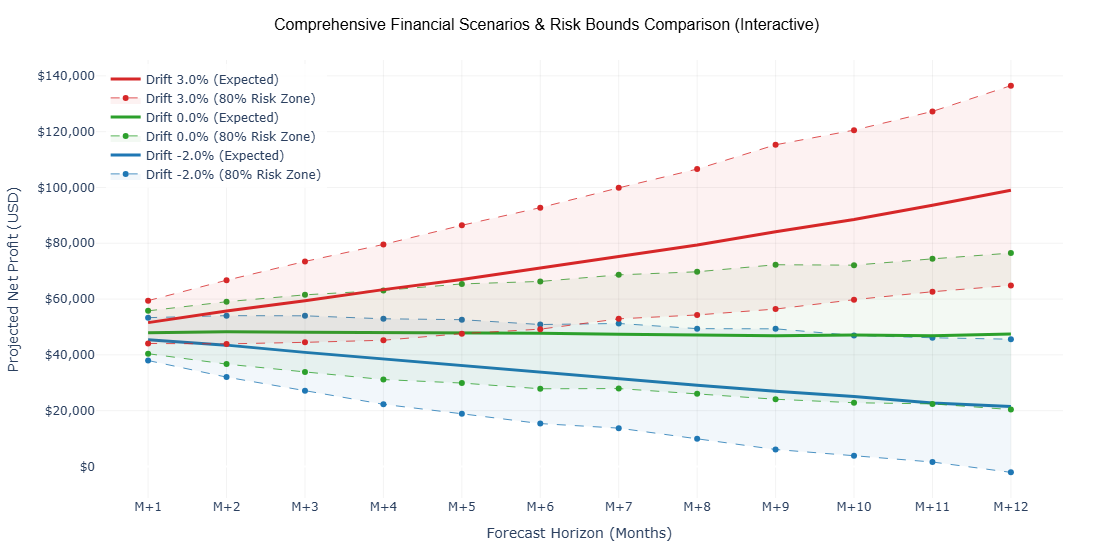


💾 網頁版圖表已成功匯出至 'financial_scenario_comparison.html'！

🎉 網頁級動態交互大圖渲染成功！
💡 高手操作指南：
1. 游標移到圖上：會自動彈出該月份所有情境的精準數字。
2. 點擊右上角工具列：可以框選放大（Zoom In）、局部平移（Pan）。
3. 雙擊圖表空白處：立刻重置回原始大小（Reset Scale）。
4. 點擊右側圖例（Legend）的標籤：可以動態隱藏/顯示該情境！


In [20]:
rev_std_pct = df_history['Actual_Revenue'].pct_change().std()
cost_std_pct = df_history['Actual_Cost'].pct_change().std()

print("🚀 【Plotly 網頁級動態預測系統 6.0】已啟動！")

# 2. 取得經理人逗號分隔輸入
user_input = input("\n💬 Please enter multiple drift rates (e.g., 0, 0.02, -0.01): ")

if user_input.strip() == "":
    print("👋 No input detected.")
else:
    try:
        drift_list = [float(x.strip()) for x in user_input.split(',') if x.strip() != ""]
        months_future = [f"M+{i}" for i in range(1, 13)]
        
        # 建立 Plotly 畫布
        fig = go.Figure()
        
        # 精選高階簡報配色 (rgba 格式)
        color_palette = [
            {'main': 'rgba(31,119,180,1)', 'fill': 'rgba(31,119,180,0.06)'},  # 藍
            {'main': 'rgba(44,160,44,1)',  'fill': 'rgba(44,160,44,0.06)'},   # 綠
            {'main': 'rgba(214,39,40,1)',  'fill': 'rgba(214,39,40,0.06)'},   # 紅
            {'main': 'rgba(148,103,189,1)', 'fill': 'rgba(148,103,189,0.06)'} # 紫
        ]
        
        # 3. 循環模擬每一種情境，並直接畫到畫布上
        for idx, target_drift in enumerate(drift_list):
            np.random.seed(42)
            simulations = 1000
            rev_sims = np.zeros((simulations, 12))
            cost_sims = np.zeros((simulations, 12))
            
            for i in range(simulations):
                cur_rev = 122000   
                cur_cost = 74000   
                for m in range(12):
                    cur_rev = cur_rev * (1 + np.random.normal(target_drift, rev_std_pct))
                    cur_cost = cur_cost * (1 + np.random.normal(0, cost_std_pct))
                    rev_sims[i, m] = cur_rev
                    cost_sims[i, m] = cur_cost
                    
            profit_sims = rev_sims - cost_sims
            p10 = np.percentile(profit_sims, 10, axis=0)
            p50 = np.percentile(profit_sims, 50, axis=0)
            p90 = np.percentile(profit_sims, 90, axis=0)
            
            cp = color_palette[idx % len(color_palette)]
            label_text = f"Drift {target_drift*100:.1f}%"
            
            # 畫 P90 虛線
            fig.add_trace(go.Scatter(
                x=months_future, y=p90,
                line=dict(color=cp['main'], width=0.8, dash='dash'),
                showlegend=False,
                hoverinfo='skip'
            ))
            
            # 畫 P10 虛線並自動渲染包夾陰影
            fig.add_trace(go.Scatter(
                x=months_future, y=p10,
                fill='tonexty',
                fillcolor=cp['fill'],
                line=dict(color=cp['main'], width=0.8, dash='dash'),
                name=f"{label_text} (80% Risk Zone)",
                hoverinfo='skip'
            ))
            
            # 畫中間的 P50 主線（🌟 核心修復：使用雙大括號保護 Plotly 特殊變數）
            fig.add_trace(go.Scatter(
                x=months_future, y=p50,
                mode='lines',
                line=dict(color=cp['main'], width=3),
                name=f"{label_text} (Expected)",
                hovertemplate=f"<b>{label_text}</b><br>Month: %{{x}}<br>Expected Profit: $%{{y:,.0f}}<br><extra></extra>"
            ))
            
        # 4. 設定圖表的進階響應式佈局
        fig.update_layout(
            title=dict(
                text="Comprehensive Financial Scenarios & Risk Bounds Comparison (Interactive)",
                font=dict(size=16, family="Arial", color="black"),
                x=0.5
            ),
            xaxis=dict(title="Forecast Horizon (Months)", gridcolor="rgba(0,0,0,0.05)"),
            yaxis=dict(title="Projected Net Profit (USD)", gridcolor="rgba(0,0,0,0.05)", tickformat="$,.0f"),
            plot_bgcolor="white",
            hovermode="x unified",
            legend=dict(
                yanchor="top", y=0.99,
                xanchor="left", x=0.01,
                bgcolor="rgba(255,255,255,0.8)"
            ),
            margin=dict(l=50, r=30, t=60, b=50),
            height=550
        )
        
        # 秀出圖表
        # 1. 在 Jupyter Notebook 裡顯示互動圖
        fig.show(config={'scrollZoom': True})
        
        # 🌟 核心加碼：一秒把整張大圖打包成獨立網頁檔案！
        fig.write_html("financial_scenario_comparison.html", config={'scrollZoom': True})
        
        print("\n💾 網頁版圖表已成功匯出至 'financial_scenario_comparison.html'！")
        print("\n🎉 網頁級動態交互大圖渲染成功！")
        print("💡 高手操作指南：")
        print("1. 游標移到圖上：會自動彈出該月份所有情境的精準數字。")
        print("2. 點擊右上角工具列：可以框選放大（Zoom In）、局部平移（Pan）。")
        print("3. 雙擊圖表空白處：立刻重置回原始大小（Reset Scale）。")
        print("4. 點擊右側圖例（Legend）的標籤：可以動態隱藏/顯示該情境！")
        
    except ValueError:
        print("❌ Input parsing error! Format should be like: 0, 0.02, -0.01")